In [ ]:
pip install scikit-learn

In [3]:
# Algoritmos de aprendizagem
# Regressão: Prever um atributo de valor contínuo associado a um objeto.

# Importação das Bibliotecas
from matplotlib import pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

# Implementa modelos de regressão 
from sklearn import linear_model
# Métricas de avaliação (R², MSE, MAE)
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
# Divide dados em treino/teste
from sklearn.model_selection import train_test_split
# Calcula raiz quadrada (RMSE)
from math import sqrt

In [4]:
# Carregar o conjunto de dados sobre consumo de combustível
df_combustível = pd.read_csv('FuelConsumptionCo2.csv');
print(df_combustível.head());

   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  
1                   

In [8]:
# Exibir informações sobre o conjunto de dados
display(df_combustível.describe());

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
# Selecionar as features dos motores e emissão de C02
engines = df_combustível[['ENGINESIZE']];
C02 = df_combustível[['CO2EMISSIONS']];

print(engines.head());

   ENGINESIZE
0         2.0
1         2.4
2         1.5
3         3.5
4         3.5


In [9]:
# Dividir os dados em conjunto de treinamento e teste 
#(80% para treinamento, 20% para teste)
engines_train, engines_test, C02_train, C02_test = train_test_split(engines,
                                                                   C02, test_size=0.2, random_state=42)
print(type(engines_train));

<class 'pandas.core.frame.DataFrame'>


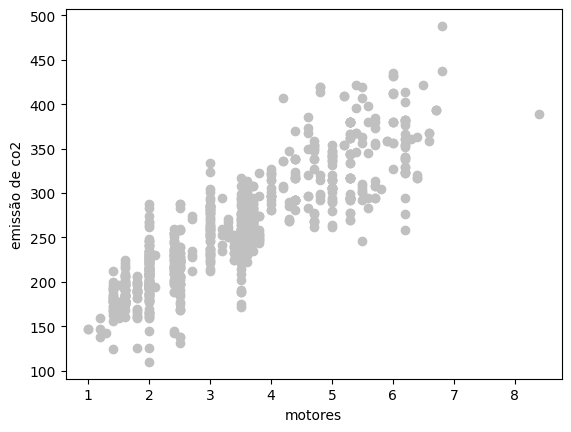

In [14]:
plt.scatter(engines_train, C02_train, 
            color='#C0C0C0');
plt.xlabel('motores');
plt.ylabel('emissão de co2');
plt.show();

In [16]:
# Criar o modelo de classificação
model = linear_model.LinearRegression();

# Treinar o modelo usando o conjunto de treinamento
# Encontrar o valor de A e B(y = A + B.x)
model.fit(engines_train, C02_train);

print('a = ', model.intercept_);
print('b = ', model.coef_);

a =  [126.28970217]
b =  [[38.99297872]]


In [17]:
# Fazer previsões sobre o conjunto de teste
predictions_C02 = model.predict(engines_test);

# Avaliar a precisão do modelo
accuracy = model.score(engines_test, C02_test)
print("acurácia do modelo:", accuracy)
# O modelo linear explica 76.2% da variância do CO2 a partir do motor.
# Isso significa que o modelo tem uma performance razoavelmente boa, mas ainda há margem para melhorias

acurácia do modelo: 0.7615595731934373


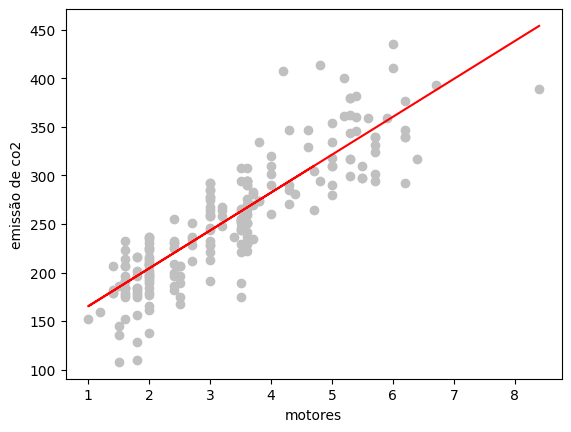

In [18]:
# Exibir a reta de regressão no conjunto de teste
plt.scatter(engines_test, C02_test, 
            color='#C0C0C0');
plt.plot(engines_test, model.coef_[0][0]*engines_test+model.intercept_[0], '-r');

plt.xlabel('motores');
plt.ylabel('emissão de co2');
plt.show();

In [24]:
# Visualizar os Resultados (Avaliar o modelo)
print(f'======% Soma dos Erros ao Quadrado (SSE): {np.sum((np.array(predictions_C02) - np.array(C02_test))**2):.2f}');
print(f'======% Erro Quadrático Médio (MSE): {mean_squared_error(C02_test, predictions_C02):.2f}');
print(f'======% Erro Médio Absoluto (MAE): {mean_absolute_error(C02_test, predictions_C02):.2f}');
print(f'======% Raiz do Erro Quadrático Médio (RMSE): {sqrt(mean_squared_error(C02_test, predictions_C02)):.2f}');
print(f'======% R²_SCORE: {r2_score(C02_test, predictions_C02):.2f}');

======% Soma dos Erros ao Quadrado (SSE): 210990.77
======% Erro Quadrático Médio (MSE): 985.94
======% Erro Médio Absoluto (MAE): 24.10
======% Raiz do Erro Quadrático Médio (RMSE): 31.40
======% R²_SCORE: 0.76
